<a href="https://colab.research.google.com/github/Pranjli-S/DS-Assignments-2026/blob/main/Movie_Production_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Section: NumPy Fundamentals (Assignment Tasks) ---
Original 2D Array Shape: (10, 10)
Transposed Array Shape: (10, 10)
Reshaped 3D Array Shape: (2, 4, 2)
All NumPy operations completed successfully.
------------------------------

--- Q1: Highest Profit Movie ---
Title: Furious 7 | Profit: $1,316,249,360

--- Q2: Top ROI Language ---
ko

--- Q3: Unique Genres ---
[np.str_('Action'), np.str_('Adventure'), np.str_('Animation'), np.str_('Comedy'), np.str_('Crime'), np.str_('Documentary'), np.str_('Drama'), np.str_('Family'), np.str_('Fantasy'), np.str_('Foreign'), np.str_('History'), np.str_('Horror'), np.str_('Music'), np.str_('Mystery'), np.str_('Romance'), np.str_('Science Fiction'), np.str_('TV Movie'), np.str_('Thriller'), np.str_('War'), np.str_('Western')]


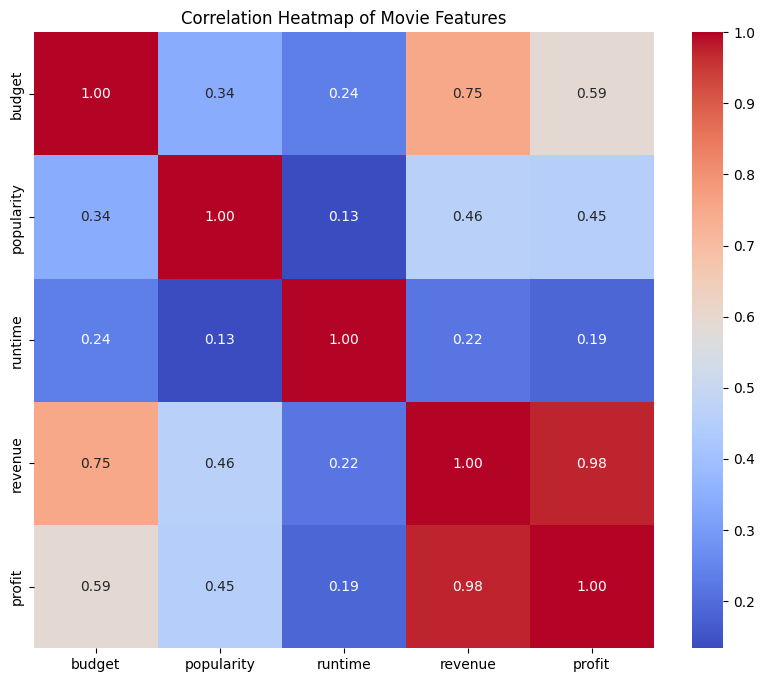

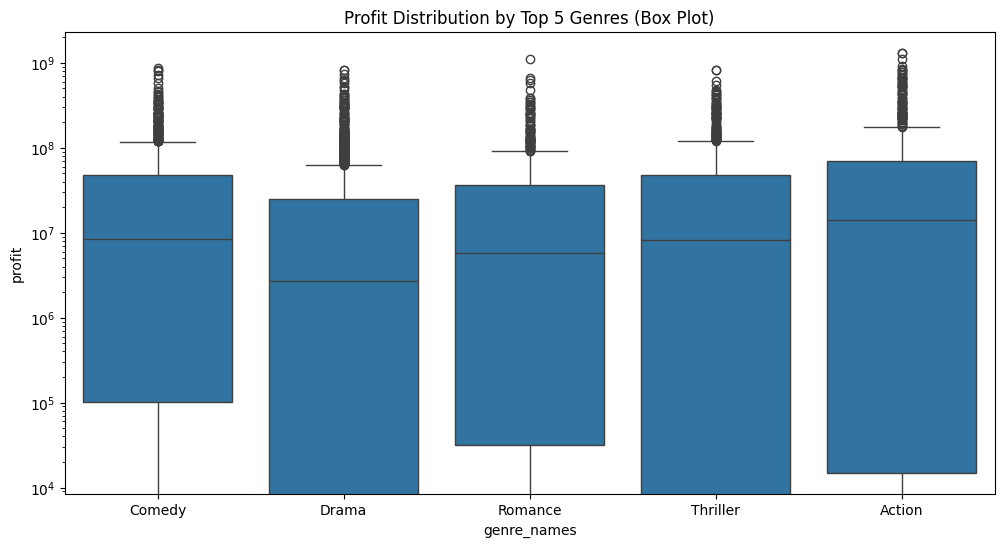

/tmp/ipykernel_2687/2423839237.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pref.index, y=pref.values, palette="viridis")


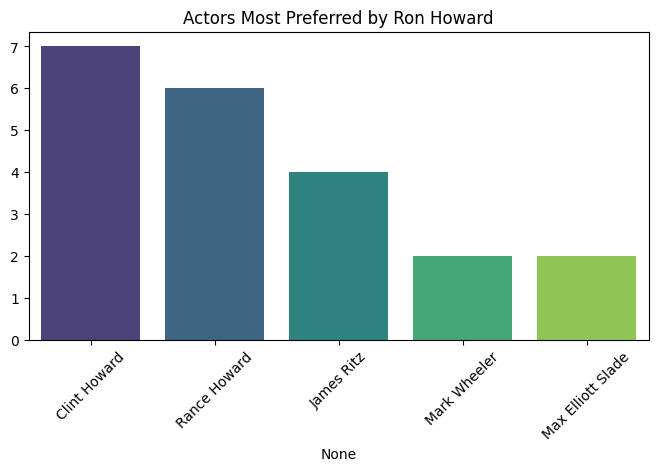

/tmp/ipykernel_2687/2423839237.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pref.index, y=pref.values, palette="viridis")


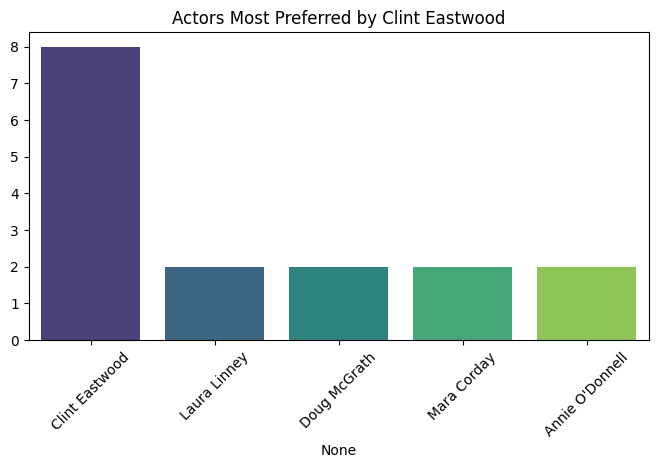

/tmp/ipykernel_2687/2423839237.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pref.index, y=pref.values, palette="viridis")


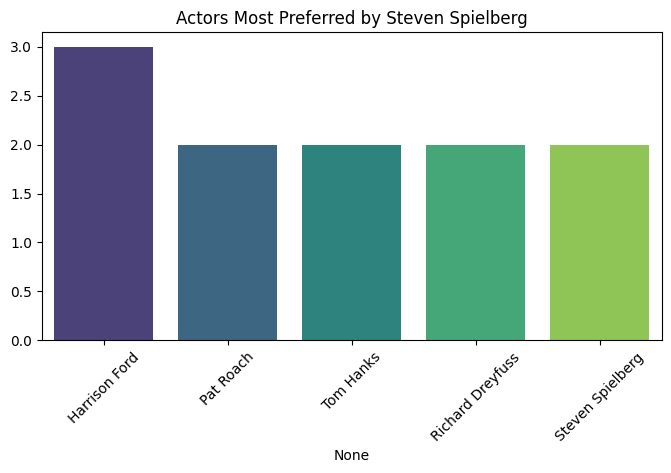

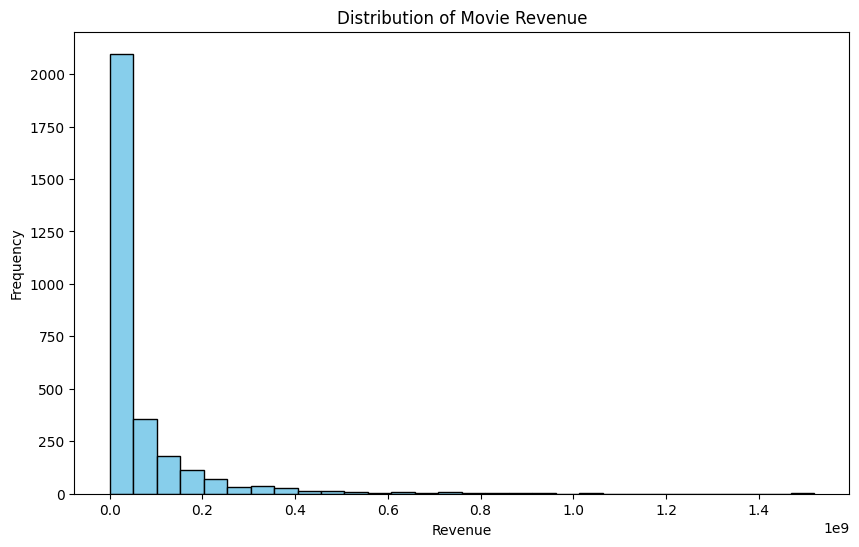

In [3]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datetime import datetime, date, timedelta

# ==========================================
# 2. NUMPY OPERATIONS
# ==========================================
print("--- Section: NumPy Fundamentals (Assignment Tasks) ---")

# 2D Array & Transpose
kim = np.array(np.random.randint(20, 90, (10, 10)))
andes = np.transpose(kim)
print(f"Original 2D Array Shape: {kim.shape}")
print(f"Transposed Array Shape: {andes.shape}")

# 3D Array & Reshaping
random_3d_array = np.array(np.random.randint(20, 90, (3, 2, 4)))
cohort = np.array(np.random.randint(20, 90, (2, 8)))
reshaped_cohort = np.reshape(cohort, (2, 4, 2))
print(f"Reshaped 3D Array Shape: {reshaped_cohort.shape}")

# Resize, Flatten, and Unique
r3D_cohort = np.array(np.random.randint(20, 95, (2, 4, 6)))
r3D_cohort.resize((2, 3, 6))
flattened_f = r3D_cohort.flatten(order='F')
unique_vals, counts = np.unique(r3D_cohort, return_counts=True)

# Insert, Append, and Delete
a_np = np.random.randint(20, 30, (2, 3, 4))
inserted = np.insert(a_np, 1, 100, axis=0)
appended = np.append(a_np, 50)
deleted = np.delete(a_np, 0, axis=1)

# Broadcasting & Arithmetic
broadcasting_example = np.ones((3, 3)) + np.arange(3)
a_math = np.random.randint(2, 6, (2, 4))
b_math = np.random.randint(0, 5, (2, 4))
product_result = np.multiply(a_math, b_math)

print("All NumPy operations completed successfully.")
print("-" * 30 + "\n")

# ==========================================
# 3. MOVIE DATA LOADING & CLEANING
# ==========================================
# Ensure 'imdb_data.csv' is uploaded to the Colab 'Files' section
df = pd.read_csv('imdb_data.csv')

def parse_json(val):
    if pd.isna(val): return []
    try: return ast.literal_eval(val)
    except: return []

df['genres_list'] = df['genres'].apply(parse_json)
df['cast_list'] = df['cast'].apply(parse_json)
df['crew_list'] = df['crew'].apply(parse_json)

df['genre_names'] = df['genres_list'].apply(lambda x: [i['name'] for i in x])
df['cast_names'] = df['cast_list'].apply(lambda x: [i['name'] for i in x])
df['director_names'] = df['crew_list'].apply(lambda x: [i['name'] for i in x if i['job'] == 'Director'])
df['producer_names'] = df['crew_list'].apply(lambda x: [i['name'] for i in x if i['job'] == 'Producer'])

# ==========================================
# 4. ANALYSIS ANSWERS
# ==========================================
df['profit'] = df['revenue'] - df['budget']
top_movie = df.loc[df['profit'].idxmax()]
print("--- Q1: Highest Profit Movie ---")
print(f"Title: {top_movie['title']} | Profit: ${top_movie['profit']:,}")

df_roi = df[df['budget'] > 0].copy()
df_roi['roi'] = (df_roi['revenue'] - df_roi['budget']) / df_roi['budget']
print(f"\n--- Q2: Top ROI Language ---\n{df_roi.groupby('original_language')['roi'].mean().idxmax()}")

print(f"\n--- Q3: Unique Genres ---\n{sorted(list(np.unique([g for sub in df['genre_names'] for g in sub])))}")

# ==========================================
# 5. EXPLORATORY DATA ANALYSIS (EDA) PLOTS
# ==========================================

# 1. CORRELATION MAP (Heatmap)
# Shows how budget, popularity, and revenue relate to each other
plt.figure(figsize=(10, 8))
numeric_df = df[['budget', 'popularity', 'runtime', 'revenue', 'profit']].dropna()
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Movie Features")
plt.show()

# 2. BOX PLOT (Profit Distribution)
# Shows the profit range and outliers for the Top 5 Genres
df_exp = df.explode('genre_names')
top_5_genres = df_exp['genre_names'].value_counts().head(5).index
df_plot = df_exp[df_exp['genre_names'].isin(top_5_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='genre_names', y='profit', data=df_plot)
plt.yscale('log') # Log scale handles the massive range in movie profits
plt.title("Profit Distribution by Top 5 Genres (Box Plot)")
plt.show()

# 3. BAR PLOT (Director Preferences)
# Visualizes which actors the Top 3 directors cast most often
top_3_dirs = pd.Series([d for sub in df['director_names'] for d in sub]).value_counts().head(3).index
for d in top_3_dirs:
    d_acts = [a for sub in df[df['director_names'].apply(lambda x: d in x)]['cast_names'] for a in sub]
    pref = pd.Series(d_acts).value_counts().head(5)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=pref.index, y=pref.values, palette="viridis")
    plt.title(f"Actors Most Preferred by {d}")
    plt.xticks(rotation=45)
    plt.show()

# 4. HISTOGRAM (Run Margin Distribution - from your cricket assignment style)
plt.figure(figsize=(10, 6))
plt.hist(df['revenue'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Movie Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()